

## **Cloning Repository**

In [ ]:
# 1. Clone the ML4SCI/CMS repository
!git clone https://github.com/ML4SCI/CMS.git

# 2. Navigate to the specific Hybrid Transformer project directory
%cd CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen

# 3. Install required libraries
!pip install lgatr uproot awkward tqdm vector

Cloning into 'CMS'...
remote: Enumerating objects: 675, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 675 (delta 14), reused 9 (delta 3), pack-reused 621 (from 2)
Receiving objects: 100% (675/675), 328.50 MiB | 19.75 MiB/s, done.
Resolving deltas: 100% (162/162), done.
Updating files: 100% (470/470), done.
/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.4/395.4 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 20.8 MB/s eta 0:00:00


In [ ]:
import urllib.request
import hashlib
import os


#Choosing Dataset

In [ ]:

def download_and_verify(url, expected_md5, filename):
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)

    # Calculate MD5
    hasher = hashlib.md5()
    with open(filename, 'rb') as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)

    actual_md5 = hasher.hexdigest()

    if actual_md5 == expected_md5:
        print(f"Success! MD5 matches: {actual_md5}")
    else:
        print(f"Checksum mismatch! \nExpected: {expected_md5}\nActual:   {actual_md5}")

# Your specific file data
url = 'https://zenodo.org/record/6619768/files/JetClass_Pythia_val_5M.tar'
md5_hash = '7235ccb577ed85023ea3ab4d5e6160cf'
out_file = 'JetClass_Pythia_val_5M.tar'

download_and_verify(url, md5_hash, out_file)

Success! MD5 matches: 7235ccb577ed85023ea3ab4d5e6160cf


In [ ]:
from google.colab import drive
import shutil

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''
drive_dest_folder = '/content/drive/MyDrive/GSOC/dara'
drive_dest_path = os.path.join(drive_dest_folder, out_file)

# Create the directory if it doesn't exist
if not os.path.exists(drive_dest_folder):
    os.makedirs(drive_dest_folder)
    print(f"Created directory: {drive_dest_folder}")

# 3. Move the verified file to Drive
if os.path.exists(out_file):
    print(f"Moving {out_file} to Google Drive...")
    shutil.move(out_file, drive_dest_path)
    print(f"File successfully moved to: {drive_dest_path}")
else:
    print("Source file not found. Check if the download was successful.")''''

In [ ]:
# --- Default libraries ---
import os
import warnings
from pathlib import Path

# --- Working directory ---
PROJECT_DIR = Path().resolve()
PROJECT_ROOT_NAME = 'Hybrid_Transformer_Thanh_Nguyen'

while PROJECT_DIR.name != PROJECT_ROOT_NAME and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent

if Path().resolve() != PROJECT_DIR:
    os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'data'
LOG_DIR = PROJECT_DIR / 'logs'

# --- Data preprocessing & visualization ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- Deep learning ---
import torch

# --- Custom modules ---
from src.configs import LorentzParTConfig, TrainConfig
from src.engine import MaskedModelTrainer, Trainer
from src.models import LorentzParT
from src.utils import accuracy_metric_ce, set_seed
from src.utils.data import JetClassDataset, compute_norm_stats, read_file
from src.utils.viz import *

# --- Settings ---
warnings.filterwarnings('ignore')
set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
# Extract the tar file into the DATA_DIR
import os
from pathlib import Path

# Define DATA_DIR explicitly as the setup cell (036c2c95) has not been executed.
# Assuming current working directory is /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
PROJECT_DIR = Path('/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen')
DATA_DIR = PROJECT_DIR / 'data'

tar_filepath = '/content/drive/MyDrive/GSOC/dara/JetClass_Pythia_val_5M.tar'#'/content/JetClass_Pythia_val_5M.tar'
extract_path = DATA_DIR

# Create the data directory if it doesn't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Extracting {tar_filepath} to {extract_path}...")
!tar -xvf {tar_filepath} -C {extract_path}
print("Extraction complete.")

Extracting /content/drive/MyDrive/GSOC/dara/JetClass_Pythia_val_5M.tar to /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen/data...
val_5M/
val_5M/HToBB_120.root
val_5M/ZToQQ_124.root
val_5M/ZJetsToNuNu_120.root
val_5M/WToQQ_124.root
val_5M/HToWW4Q_121.root
val_5M/WToQQ_122.root
val_5M/ZJetsToNuNu_124.root
val_5M/HToCC_122.root
val_5M/ZToQQ_123.root
val_5M/HToWW2Q1L_121.root
val_5M/ZToQQ_121.root
val_5M/HToWW2Q1L_124.root
val_5M/HToGG_124.root
val_5M/HToBB_123.root
val_5M/ZToQQ_122.root
val_5M/TTBar_121.root
val_5M/WToQQ_121.root
val_5M/WToQQ_120.root
val_5M/TTBar_122.root
val_5M/ZJetsToNuNu_123.root
val_5M/TTBar_124.root
val_5M/ZToQQ_120.root
val_5M/TTBarLep_124.root
val_5M/ZJetsToNuNu_122.root
val_5M/HToCC_123.root
val_5M/HToGG_122.root
val_5M/HToWW4Q_124.root
val_5M/HToCC_121.root
val_5M/HToBB_124.root
val_5M/TTBar_123.root
val_5M/ZJetsToNuNu_121.root
val_5M/HToWW4Q_120.root
val_5M/HToWW4Q_123.root
val_5M/TTBarLep_120.root
val_5M/HToWW4Q_122.root
val_5M/TTBarLep_122.root
val_5M/TTBa

### **1. Data Processing**

In [ ]:
import numpy as np
import os # Ensure os is imported here for os.listdir and os.path.join
from pathlib import Path # Add this import

# Define DATA_DIR explicitly as the setup cell (036c2c95) has not been executed.
# Assuming current working directory is /content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen
PROJECT_DIR = Path('/content/CMS/MAEs/Hybrid_Transformer_Thanh_Nguyen')
DATA_DIR = PROJECT_DIR / 'data'

# Read in the data
num_files = 10
stride = 5
data_source_directory = DATA_DIR / 'val_5M' # Point to the extracted directory containing .root files
all_xp, all_xj, all_y = [], [], []

# List .root files from the data_source_directory
root_files = [f for f in os.listdir(data_source_directory) if f.endswith('.root')]

# Select a subset of files with equally-distributed classes
# Ensure there are enough root files to select from
if len(root_files) == 0:
    print("No .root files found in the data source directory. Please ensure the tar file was extracted correctly.")
    # Handle this case, perhaps by skipping concatenation or raising an error
    # For now, we will let concatenate fail if lists are empty.
else:
    selected_files = root_files[:min(num_files * stride, len(root_files)):stride]

    for fname in selected_files:
        x_particles, x_jets, y = read_file(os.path.join(data_source_directory, fname))
        all_xp.append(x_particles)
        all_xj.append(x_jets)
        all_y.append(y)

# Concatenate all data if lists are not empty
if all_xp and all_xj and all_y:
    X_particles = np.concatenate(all_xp, axis=0)
    X_jets = np.concatenate(all_xj, axis=0)
    y = np.concatenate(all_y, axis=0)

    print(X_particles.shape, X_jets.shape, y.shape)
else:
    print("Could not read any data files. X_particles, X_jets, and y will remain empty.")

(1000000, 4, 128) (1000000, 4) (1000000, 10)


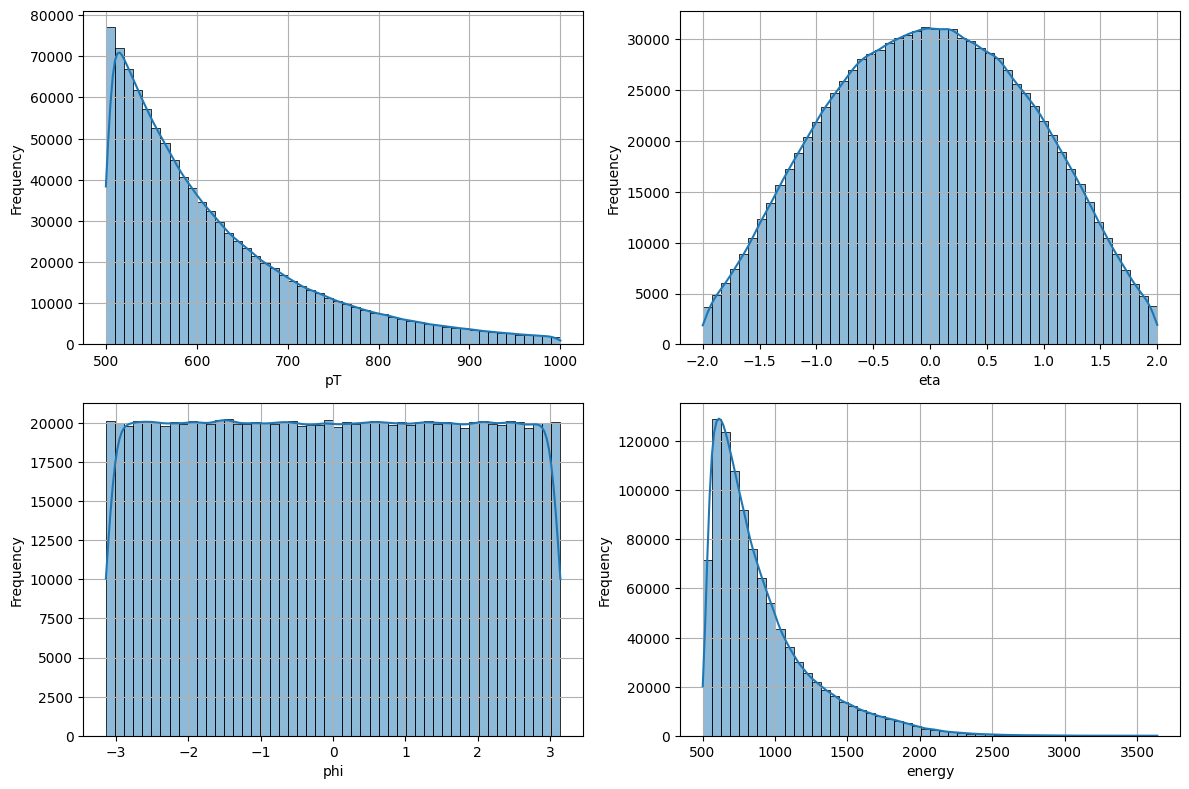

In [ ]:
# Visualize the distribution of each feature per jet
plot_feature_distribution(X_jets)

In [ ]:
# Normalize pT and energy
normalize = [True, False, False, True]
norm_dict = compute_norm_stats(X_particles)

pt_mean: 104.46350860595703, pt_std: 116.70646667480469
eta_mean: -0.0006092909025028348, eta_std: 0.9081049561500549
phi_mean: 8.528434409527108e-05, phi_std: 1.8136582374572754
E_mean: 149.4552001953125, E_std: 182.8554229736328


In [ ]:
# Randomly split the data into training, validation, and test sets
X_train, X_val, y_train, y_val = train_test_split(X_particles, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

# Datasets for self-supervised pre-training
train_dataset = JetClassDataset(X_train, y_train, normalize, norm_dict, mask_mode='biased')
val_dataset = JetClassDataset(X_val, y_val, normalize, norm_dict, mask_mode='biased')
test_dataset = JetClassDataset(X_test, y_test, normalize, norm_dict, mask_mode='first')